# Ejercicio 6 — Benchmark: Parquet directo vs. tabla DuckDB

El benchmark lo ejecuta `scripts/benchmark.py` (tarda varios minutos y genera `docs/resultados/06_benchmark.csv`).
Este notebook solo analiza y grafica esos resultados. Para re-ejecutarlo desde aquí, descomente la celda siguiente.
Las consultas medidas están en `sql/06_benchmark.sql`; el análisis está en `docs/06_benchmark.md`.

In [1]:
# !cd .. && python scripts/benchmark.py

In [2]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

os.chdir(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())
FIG = Path("docs/figuras"); FIG.mkdir(parents=True, exist_ok=True)
b = pd.read_csv("docs/resultados/06_benchmark.csv")
carga = pd.read_csv("docs/resultados/06_benchmark_carga.csv")
carga

,escenario,archivos,filas,parquet_mib,duckdb_mib,materializacion_s
0,1_mes,2,3765161,62.1,102.3,2.60
1,2026,16,30040469,495.7,816.3,10.15
2,2024+2026,40,71870407,1171.7,1940.5,21.90
3,todos,64,121184384,1977.0,3306.0,47.35


## Tabla de resultados (mediana en segundos)

In [3]:
t = b.pivot_table(index="consulta", columns=["escenario", "estrategia"], values="mediana_s")
t = t.reindex(columns=carga.escenario, level=0)
for e in carga.escenario:
    t[(e, "aceleracion")] = t[(e, "parquet")] / t[(e, "tabla")]
t = t.reindex(columns=pd.MultiIndex.from_product([carga.escenario, ["parquet", "tabla", "aceleracion"]]))
t.round(3)

escenario             1_mes                       2026                     \
                    parquet  tabla aceleracion parquet  tabla aceleracion   
consulta                                                                    
B1_conteo_total       0.080  0.000     398.500   0.178  0.000     445.750   
B2_viajes_por_mes     0.380  0.044       8.664   1.280  0.269       4.766   
B3_demanda_hora_dia   0.529  0.062       8.458   2.594  0.381       6.803   
B4_top_zonas          0.321  0.052       6.187   1.437  0.290       4.945   
B5_propinas           0.365  0.094       3.900   1.917  0.866       2.214   
B6_percentiles        1.099  0.851       1.291   8.065  7.223       1.117   
B7_un_dia             0.088  0.003      34.038   0.221  0.003      76.310   
B8_filas_completas    0.928  0.327       2.839   2.360  0.842       2.803   

escenario           2024+2026                       todos                      
                      parquet   tabla aceleracion parquet   tabla aceleracion  
consulta                                                                       
B1_conteo_total         0.286   0.000    1430.000   1.141   0.000    2853.000  
B2_viajes_por_mes       2.629   0.603       4.357   4.230   0.903       4.686  
B3_demanda_hora_dia     4.943   0.840       5.884   8.087   1.682       4.809  
B4_top_zonas            2.804   0.894       3.135   4.415   1.316       3.353  
B5_propinas             4.418   2.222       1.989   6.490   3.290       1.972  
B6_percentiles         16.844  15.155       1.111  29.340  27.221       1.078  
B7_un_dia               0.868   0.004     240.972   0.881   0.004     244.806  
B8_filas_completas      4.247   1.098       3.866   6.634   1.513       4.385

## Tiempo vs. cantidad de datos

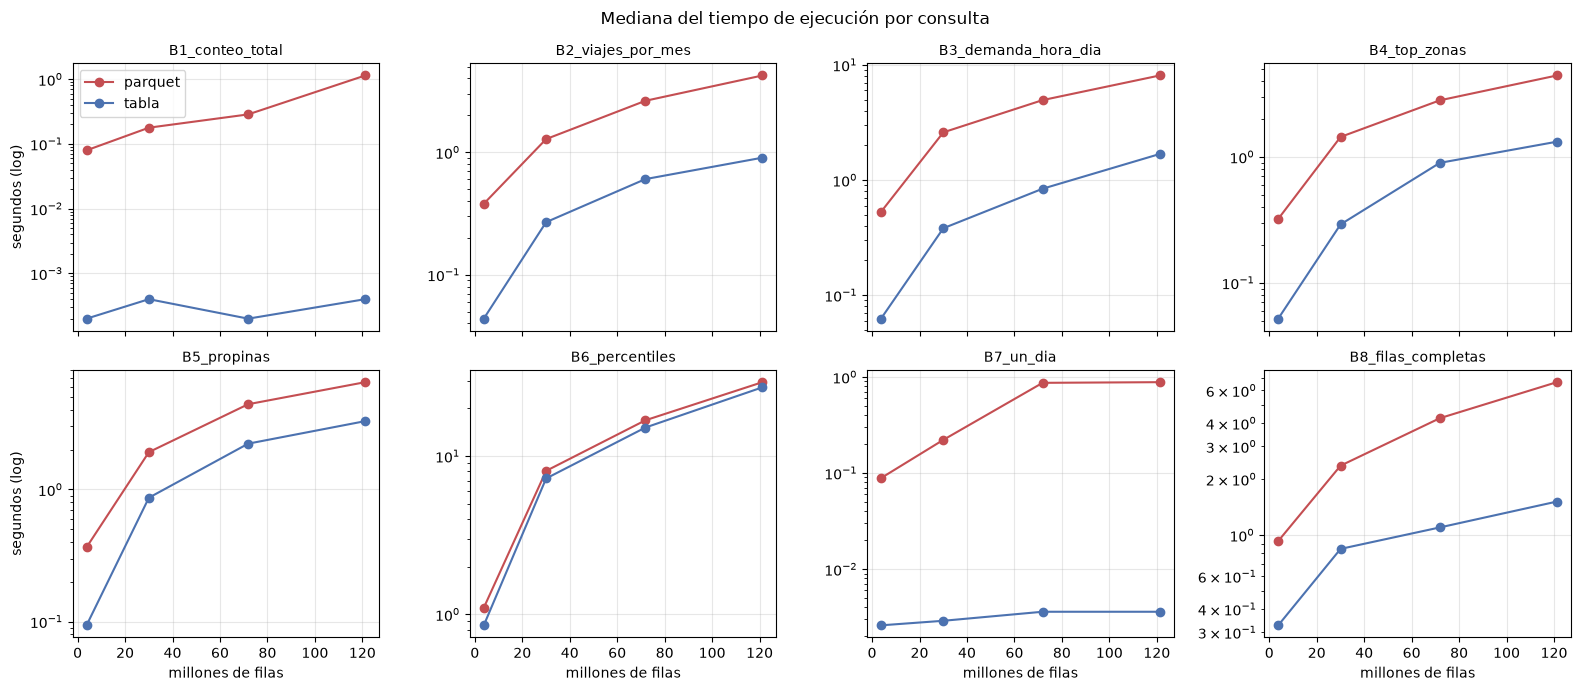

In [4]:
consultas = sorted(b.consulta.unique())
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True)
for ax, q in zip(axes.flat, consultas):
    for est, color in (("parquet", "#c44e52"), ("tabla", "#4c72b0")):
        d = b[(b.consulta == q) & (b.estrategia == est)].sort_values("filas")
        ax.plot(d.filas / 1e6, d.mediana_s, marker="o", color=color, label=est)
    ax.set_title(q, fontsize=10); ax.set_yscale("log")
    ax.grid(alpha=.3)
for ax in axes[-1]: ax.set_xlabel("millones de filas")
for ax in axes[:, 0]: ax.set_ylabel("segundos (log)")
axes[0, 0].legend()
fig.suptitle("Mediana del tiempo de ejecución por consulta")
plt.tight_layout()
fig.savefig(FIG / "06_tiempo_vs_filas.png", dpi=110, bbox_inches="tight")

## Aceleración de la tabla materializada (Parquet / tabla)

escenario,1_mes,2026,2024+2026,todos
consulta,,,,
B1_conteo_total,398.5,445.7,1430.0,2853.0
B2_viajes_por_mes,8.7,4.8,4.4,4.7
B3_demanda_hora_dia,8.5,6.8,5.9,4.8
B4_top_zonas,6.2,4.9,3.1,3.4
B5_propinas,3.9,2.2,2.0,2.0
B6_percentiles,1.3,1.1,1.1,1.1
B7_un_dia,34.0,76.3,241.0,244.8
B8_filas_completas,2.8,2.8,3.9,4.4


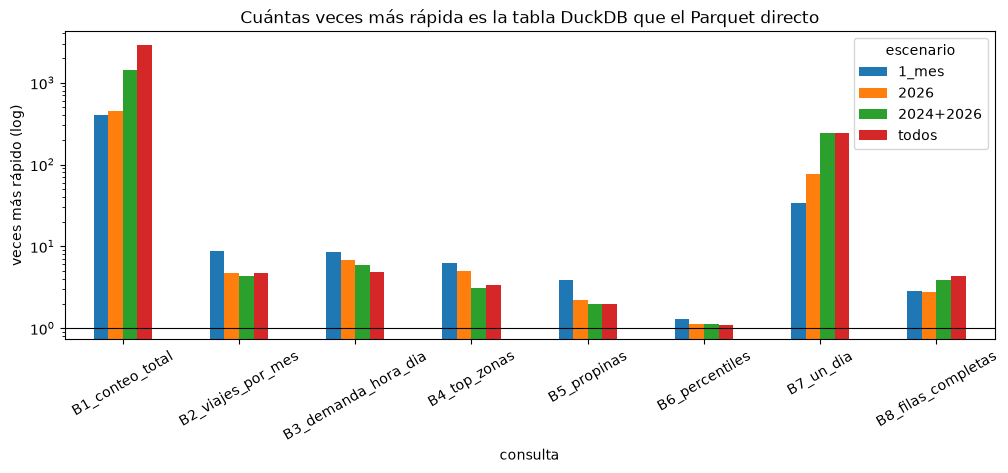

In [5]:
a = b.pivot_table(index=["escenario", "consulta"], columns="estrategia", values="mediana_s")
a["aceleracion"] = a.parquet / a.tabla
p = a.aceleracion.unstack(0)[list(carga.escenario)]
ax = p.plot.bar(figsize=(12, 4), logy=True, rot=30)
ax.axhline(1, color="black", lw=.8); ax.set_ylabel("veces más rápido (log)")
ax.set_title("Cuántas veces más rápida es la tabla DuckDB que el Parquet directo")
ax.figure.savefig(FIG / "06_aceleracion.png", dpi=110, bbox_inches="tight")
p.round(1)

## Costo de materializar

In [6]:
c = carga.copy()
c["ahorro_total_s"] = [ (b[(b.escenario == e) & (b.estrategia == "parquet")].mediana_s.sum()
                         - b[(b.escenario == e) & (b.estrategia == "tabla")].mediana_s.sum())
                        for e in c.escenario ]
c["ejecuciones_para_amortizar"] = (c.materializacion_s / c.ahorro_total_s).round(1)
c["sobrecosto_disco"] = (c.duckdb_mib / c.parquet_mib).round(2)
c

,escenario,archivos,filas,parquet_mib,duckdb_mib,materializacion_s,ahorro_total_s,ejecuciones_para_amortizar,sobrecosto_disco
0,1_mes,2,3765161,62.1,102.3,2.60,2.3565,1.1,1.65
1,2026,16,30040469,495.7,816.3,10.15,8.1788,1.2,1.65
2,2024+2026,40,71870407,1171.7,1940.5,21.90,16.2217,1.4,1.66
3,todos,64,121184384,1977.0,3306.0,47.35,25.2900,1.9,1.67
